# 05 — Training the NanoVLM

In the previous notebooks, we built each major component of our NanoVLM:

- Dataset and DataLoader
- CNN Image Encoder
- Transformer-based Text Encoder
- Symmetric CLIP-style Contrastive Loss

Now we connect these components and train them jointly.

The complete training flow is:

```text
Image
  ↓
Image Encoder
  ↓
Image Embedding
  ↓
                 Similarity Matrix
                 ↓
              Contrastive Loss
                 ↑
Text Embedding
  ↑
Text Encoder
  ↑
Tokenized Caption

In [1]:
# Core PyTorch imports

import random
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Import your existing implementations.

Random seed: 42
Number of colors: 9
Number of shapes: 3
Number of positions: 9
Expected number of samples: 243
Number of combinations: 243
red circle top-left


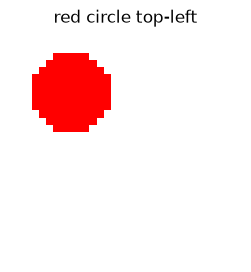

Total samples: 243


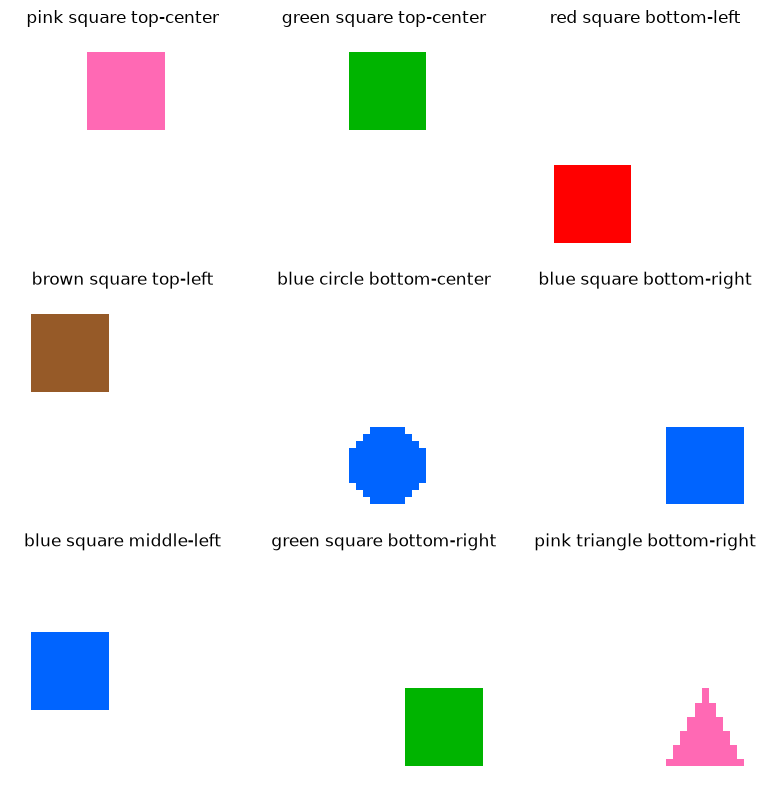

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


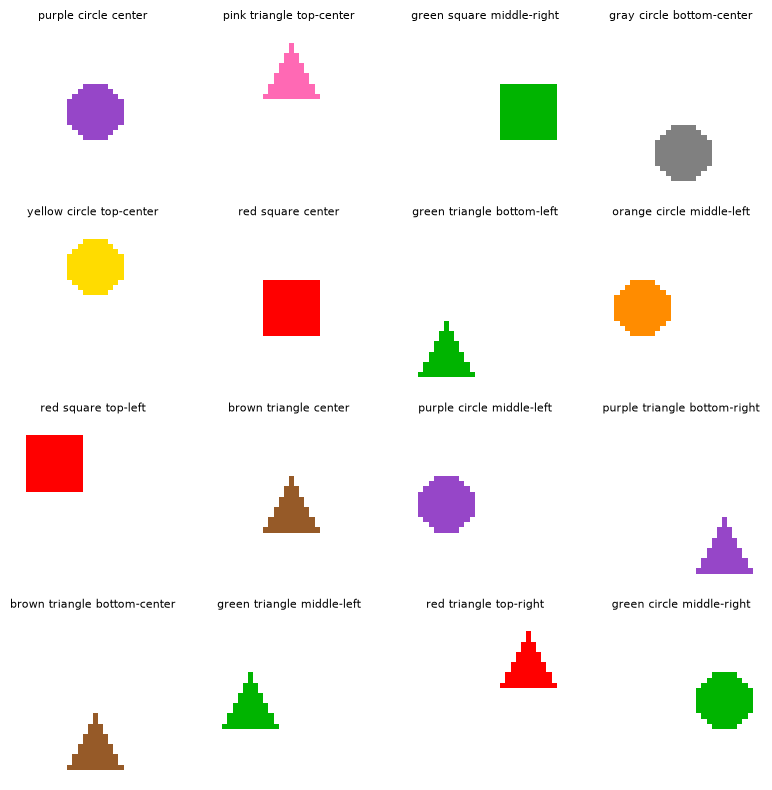

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
Random seed: 42
Number of colors: 9
Number of shapes: 3
Number of positions: 9
Expected number of samples: 243
Number of combinations: 243
red circle top-left


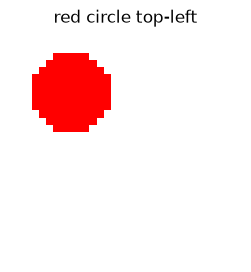

Total samples: 243


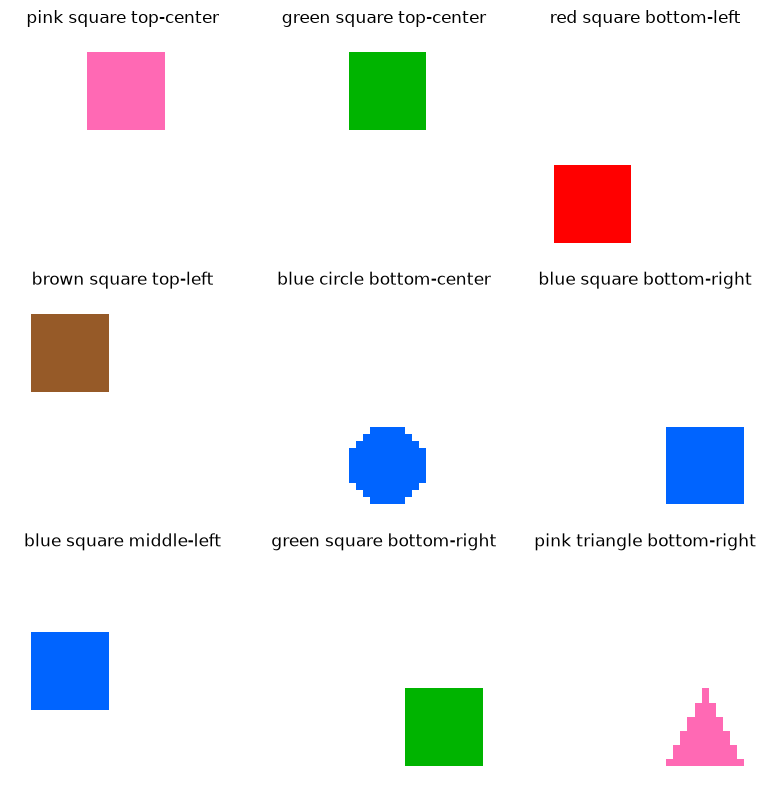

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


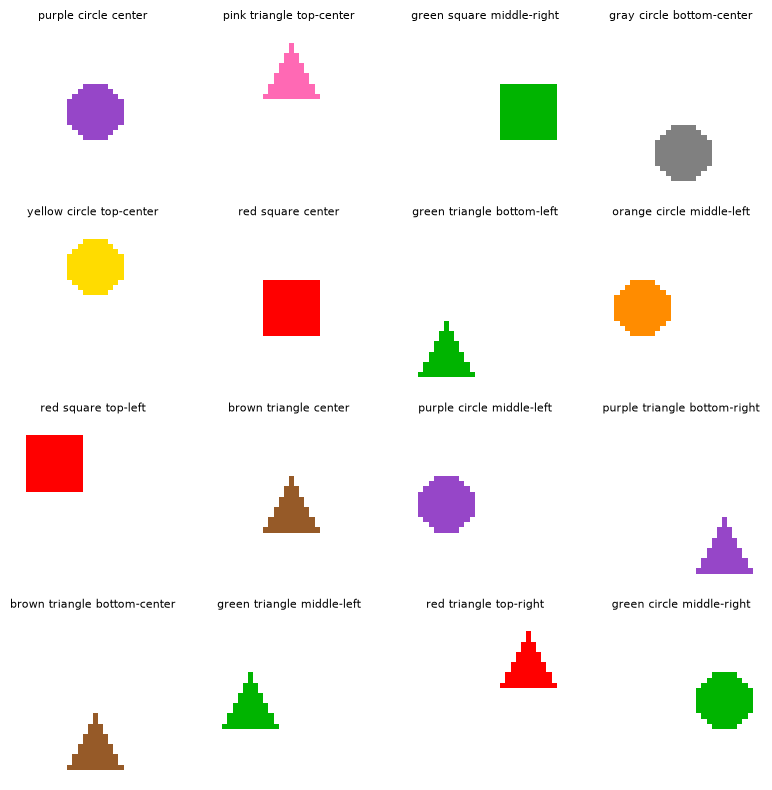

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
ImageEncoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (projection): Linear(in_features=256, out_features=64, bias=True)
)
Input shape: torch.Size([4, 3, 32, 32])
Embedding shape: torch.Size([4, 64])
✓ Output shape is correct.
Input:                   torch.Size([4, 3, 32, 32])
After Conv 1:            torch.Size([4, 32, 16, 16])
After Conv 2:            torch.Size([4, 64, 8, 8])
After Conv 3:       

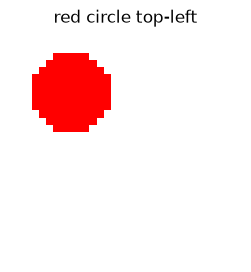

Total samples: 243


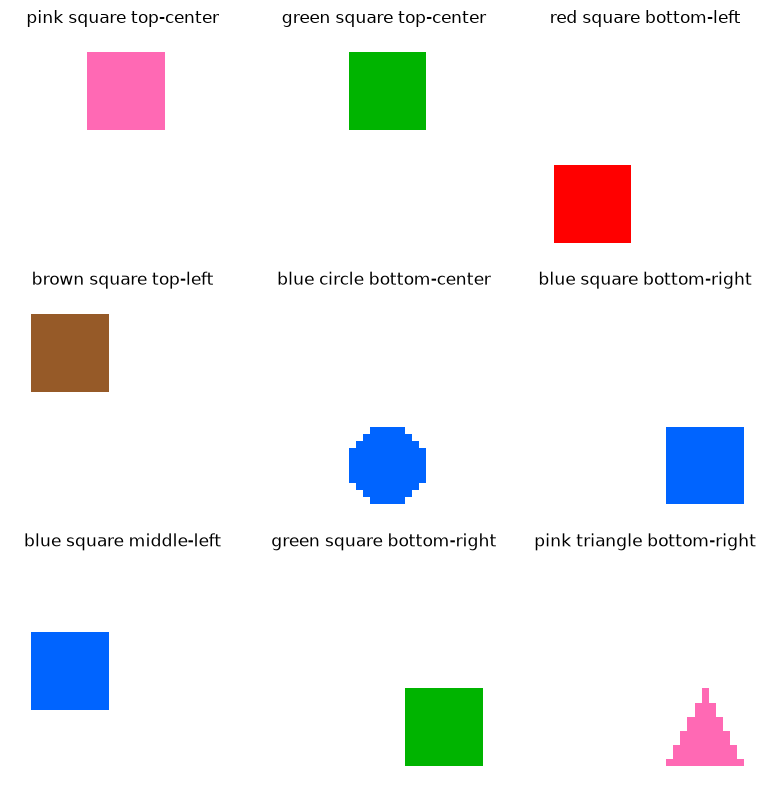

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


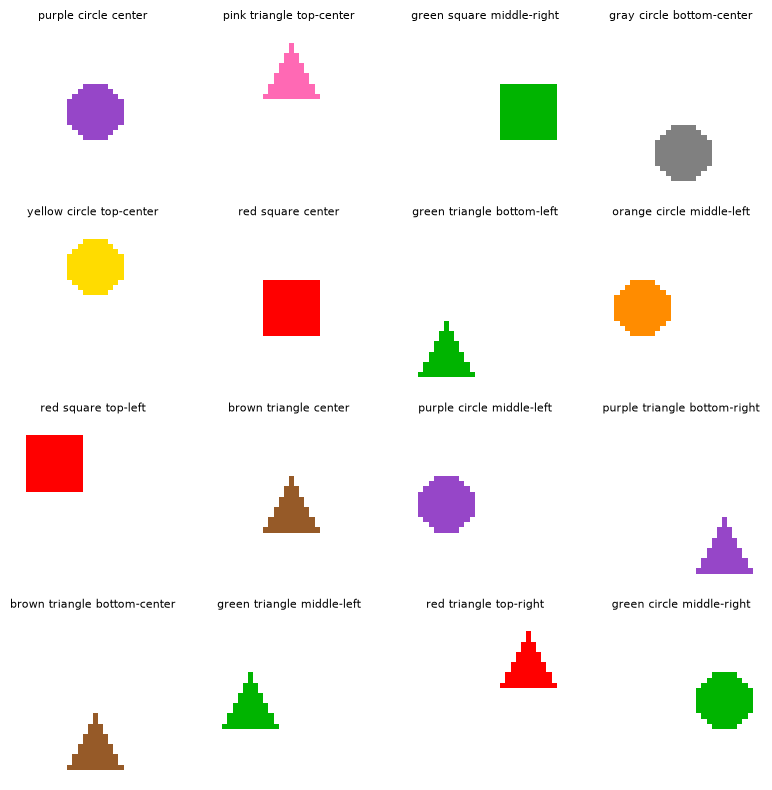

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
Batch type: <class 'dict'>
Images shape: torch.Size([32, 3, 32, 32])
Number of captions: 32
First caption: yellow triangle center
Token shape: torch.Size([32, 16])
Token dtype: torch.int64
Token device: cpu
Tokens shape:            torch.Size([32, 16])
Text embeddings shape:  torch.Size([32, 64])
Text embeddings dtype:  torch.float32
Text embeddings device: cpu
✓ Real captions successfully passed through the Text Encoder.
Random seed: 42
Number of colors: 9
Number of shapes: 3
Number of positions: 9
Expected number of samples: 243
Number of combinations: 243
red circle top-left


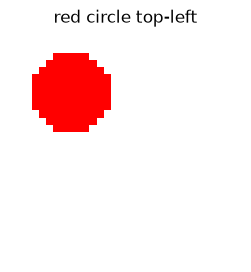

Total samples: 243


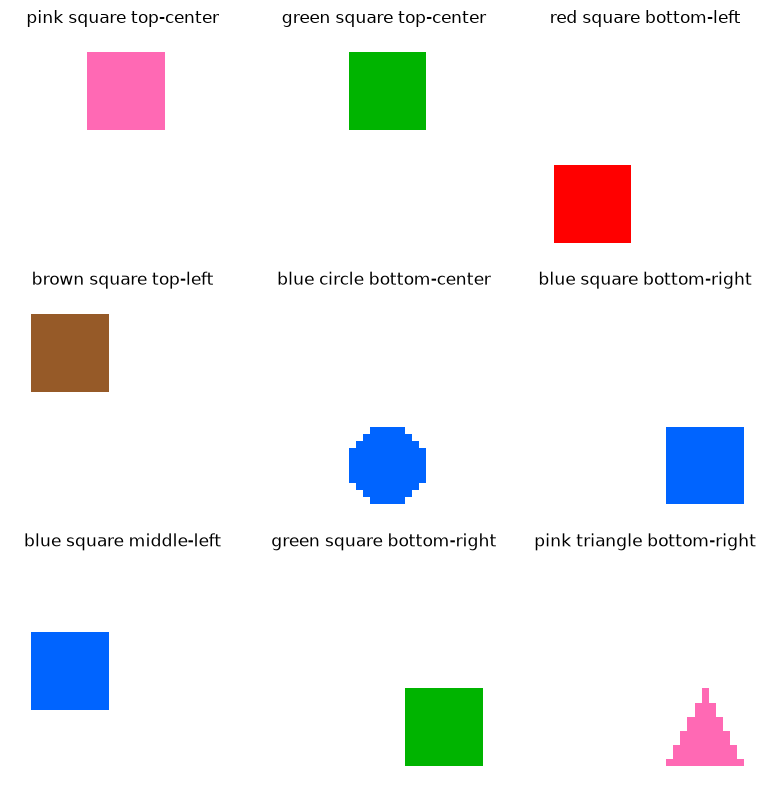

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


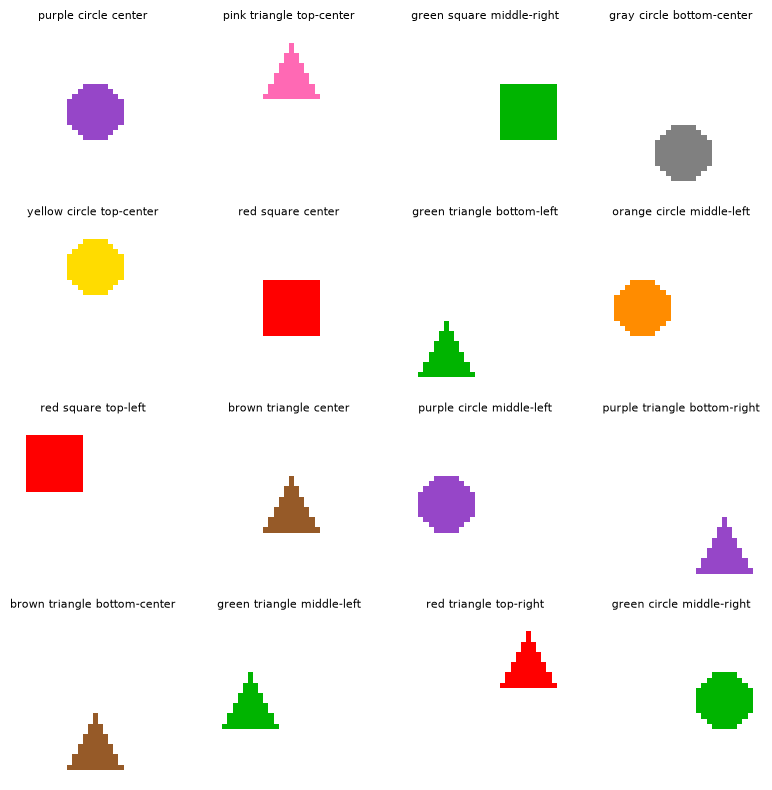

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
ImageEncoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (projection): Linear(in_features=256, out_features=64, bias=True)
)
Input shape: torch.Size([4, 3, 32, 32])
Embedding shape: torch.Size([4, 64])
✓ Output shape is correct.
Input:                   torch.Size([4, 3, 32, 32])
After Conv 1:            torch.Size([4, 32, 16, 16])
After Conv 2:            torch.Size([4, 64, 8, 8])
After Conv 3:       

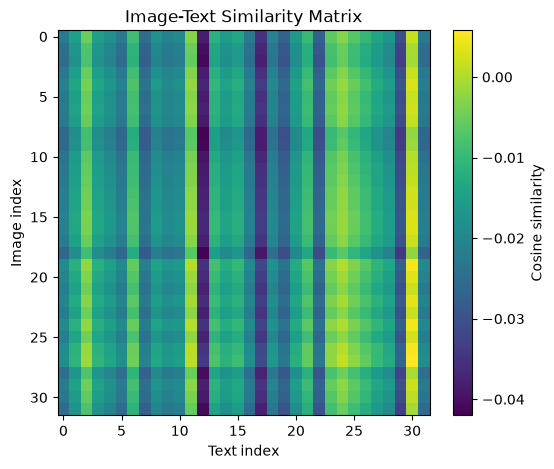

Temperature: 0.07
Logits shape: torch.Size([32, 32])
Labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
Image-to-text loss: 3.474287509918213
Text-to-image loss: 3.466135025024414
Image-to-text loss: 3.474287509918213
Text-to-image loss: 3.466135025024414
Symmetric CLIP loss: 3.4702112674713135
CLIPContrastiveLoss()
Image-to-text loss: 3.474287509918213
Text-to-image loss: 3.466135025024414
Total CLIP loss: 3.4702112674713135
Similarity shape: torch.Size([32, 32])
Toy similarity matrix:
tensor([[1., 0.],
        [0., 1.]])

Toy logits:
tensor([[10.,  0.],
        [ 0., 10.]])

Labels:
tensor([0, 1])

Image-to-text loss:
4.541770613286644e-05

Text-to-image loss:
4.541770613286644e-05

Symmetric loss:
4.541770613286644e-05
Manual loss: 4.541770613286644e-05
Class loss : 4.541770613286644e-05
✓ Manual and class implementations match.
✓ Embedding shapes are correct.
✓ Similarity matrix sh

In [14]:
# %run 01_dataset_exploration.ipynb
# %run 02_Image_Encoder.ipynb
# %run 03_Text_Encoder.ipynb
%run 04_Contrastive_Loss.ipynb

## 3. Device Configuration

Training can run on either:

- CPU
- NVIDIA GPU through CUDA

We select the device automatically.

The same device must be used by:

- images
- token tensors
- Image Encoder
- Text Encoder
- loss calculations

Keeping all tensors and model parameters on the same device prevents device mismatch errors.

In [15]:
# Reproducibility

SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Select the training device.

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


## 4. Inspect the Existing DataLoader

Before writing the training loop, we need to verify exactly what one batch from the existing DataLoader contains.

This is especially important because the DataLoader may return more than two values.

In [16]:
# Get one batch from the existing DataLoader.

batch = next(iter(train_loader))

print("Batch type:", type(batch))

if isinstance(batch, dict):
    print("Batch keys:", batch.keys())

elif isinstance(batch, (tuple, list)):
    print("Number of batch elements:", len(batch))

    for i, item in enumerate(batch):
        if torch.is_tensor(item):
            print(
                f"Element {i}: tensor | "
                f"shape={item.shape} | "
                f"dtype={item.dtype}"
            )
        else:
            print(
                f"Element {i}: "
                f"type={type(item)}"
            )

else:
    print("Batch contents:", batch)

Batch type: <class 'dict'>
Batch keys: dict_keys(['image', 'caption', 'color', 'shape', 'position'])


## 5. Extract Images and Captions from the Existing Batch

The previous cell tells us the actual DataLoader structure.

We now create a small helper that avoids hard-coding:

In [18]:
def unpack_batch(batch):
    """
    Extract images and text information from an existing DataLoader batch.

    This helper intentionally does not recreate or modify the dataset.
    """

    # --------------------------------------------------
    # Dictionary-style batch
    # --------------------------------------------------

    if isinstance(batch, dict):

        image_keys = [
            "image",
            "images",
            "pixel_values",
        ]

        text_keys = [
            "caption",
            "captions",
            "text",
            "texts",
            "tokens",
            "input_ids",
        ]

        images = None
        text = None

        for key in image_keys:
            if key in batch:
                images = batch[key]
                break

        for key in text_keys:
            if key in batch:
                text = batch[key]
                break

        if images is None or text is None:
            raise KeyError(
                "Could not identify images/text in batch dictionary. "
                f"Available keys: {list(batch.keys())}"
            )

        return images, text

    # --------------------------------------------------
    # Tuple/list-style batch
    # --------------------------------------------------

    if isinstance(batch, (tuple, list)):

        # Find the image tensor.
        image_candidates = [
            item
            for item in batch
            if torch.is_tensor(item)
            and item.ndim == 4
        ]

        if len(image_candidates) == 0:
            raise ValueError(
                "Could not find an image tensor with "
                "shape [B, C, H, W] in the batch."
            )

        images = image_candidates[0]

        # Find a likely text object.
        for item in batch:

            if item is images:
                continue

            # Token IDs
            if torch.is_tensor(item) and item.ndim == 2:
                return images, item

            # Captions as strings
            if isinstance(item, (list, tuple)):
                if len(item) > 0 and isinstance(
                    item[0],
                    str,
                ):
                    return images, item

        raise ValueError(
            "Found images but could not identify captions "
            "or token IDs in the batch."
        )

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )

In [19]:
# Test the batch extraction helper.

images, text_data = unpack_batch(batch)

print("Images shape:", images.shape)
print("Text data type:", type(text_data))

if torch.is_tensor(text_data):
    print("Text tensor shape:", text_data.shape)
    print("Text tensor dtype:", text_data.dtype)

elif isinstance(text_data, (list, tuple)):
    print("Number of text items:", len(text_data))

    if len(text_data) > 0:
        print("First caption:", text_data[0])

Images shape: torch.Size([32, 3, 32, 32])
Text data type: <class 'list'>
Number of text items: 32
First caption: yellow circle bottom-left


## 6. Create the Models

We now instantiate the two encoders.

The architecture itself is unchanged.

The Image Encoder produces:

$$
z_I \in \mathbb{R}^{64}
$$

The Text Encoder also produces:

$$
z_T \in \mathbb{R}^{64}
$$

Both models are moved to the selected device.

The contrastive loss itself has no learnable parameters in our current implementation, so it does not need to be moved to the device.

In [21]:
# Create the Image Encoder.

image_encoder = ImageEncoder().to(DEVICE)


# Create the Text Encoder.
#
# Reuse the configuration variables already defined
# by the Text Encoder notebook/module.

text_encoder = TextEncoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_length=CONTEXT_WINDOW,
    attention_heads=ATTENTION_HEADS,
    projection_dim=PROJECTION_DIM,
).to(DEVICE)


# Create the contrastive loss.

contrastive_loss_fn = CLIPContrastiveLoss(
    temperature=0.07,
)


print("Image Encoder:")
print(image_encoder)

print("\nText Encoder:")
print(text_encoder)

print("\nContrastive Loss:")
print(contrastive_loss_fn)

Image Encoder:
ImageEncoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (projection): Linear(in_features=256, out_features=64, bias=True)
)

Text Encoder:
TextEncoder(
  (token_embedding): Embedding(25, 64, padding_idx=0)
  (position_embedding): Embedding(16, 64)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (projection): Linear(in_features=64, out_features=64, bias=True)
)

Contrastive Loss:
CLIPContrastiveLoss()


## 7. Optimizer

The optimizer must update parameters from **both encoders**.

The contrastive loss connects the two modalities, but the encoders contain the trainable parameters.

Therefore:

```text
Image Encoder parameters ──┐
                            ├──→ Optimizer
Text Encoder parameters  ──┘

In [22]:
# Training hyperparameters

LEARNING_RATE = 1e-3
NUM_EPOCHS = 20


# One optimizer for BOTH encoders.

optimizer = torch.optim.Adam(
    list(image_encoder.parameters())
    + list(text_encoder.parameters()),
    lr=LEARNING_RATE,
)


print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)

Learning rate: 0.001
Epochs: 20


## 8. Preparing Text for the Text Encoder

The existing DataLoader may provide either:

1. raw caption strings, or
2. token IDs.

We should not tokenize already-tokenized data a second time.

Therefore the training step checks the type of the text data.

If it is already a tensor:

```text
captions/tokens
↓
Text Encoder

In [23]:
def prepare_text(text_data):
    """
    Convert the DataLoader's text output into token IDs.

    If text_data is already a tensor, it is returned unchanged.

    If text_data contains strings, the existing tokenizer function
    from the Text Encoder notebook is used.
    """

    if torch.is_tensor(text_data):
        return text_data

    if isinstance(text_data, (list, tuple)):
        if len(text_data) == 0:
            raise ValueError("Empty text batch.")

        if isinstance(text_data[0], str):

            return tokenize_captions(
                text_data,
                max_length=CONTEXT_WINDOW,
            )

    raise TypeError(
        "Unsupported text batch format: "
        f"{type(text_data)}"
    )

## 9. One Training Step

A single training step follows this sequence:

```text
Batch
 ↓
Images + Captions
 ↓
Move to DEVICE
 ↓
Image Encoder
 ↓
Image Embeddings [B, 64]

Captions
 ↓
Tokenizer / Token IDs
 ↓
Text Encoder
 ↓
Text Embeddings [B, 64]

Image Embeddings + Text Embeddings
 ↓
Contrastive Loss
 ↓
Scalar Loss
 ↓
Backward
 ↓
Optimizer Step

In [24]:
def train_one_epoch(
    image_encoder,
    text_encoder,
    train_loader,
    contrastive_loss_fn,
    optimizer,
    device,
):
    """
    Train both encoders for one complete epoch.
    """

    image_encoder.train()
    text_encoder.train()

    total_loss = 0.0
    num_batches = 0

    for batch in train_loader:

        # ----------------------------------------------
        # 1. Extract images and text
        # ----------------------------------------------

        images, text_data = unpack_batch(batch)

        # ----------------------------------------------
        # 2. Prepare text
        # ----------------------------------------------

        tokens = prepare_text(text_data)

        # ----------------------------------------------
        # 3. Move tensors to device
        # ----------------------------------------------

        images = images.to(device)
        tokens = tokens.to(device)

        # ----------------------------------------------
        # 4. Clear previous gradients
        # ----------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------
        # 5. Forward pass
        # ----------------------------------------------

        image_embeddings = image_encoder(images)

        text_embeddings = text_encoder(tokens)

        # ----------------------------------------------
        # 6. Contrastive loss
        # ----------------------------------------------

        loss = contrastive_loss_fn(
            image_embeddings,
            text_embeddings,
        )

        # ----------------------------------------------
        # 7. Backpropagation
        # ----------------------------------------------

        loss.backward()

        # ----------------------------------------------
        # 8. Update both encoders
        # ----------------------------------------------

        optimizer.step()

        # ----------------------------------------------
        # 9. Accumulate loss
        # ----------------------------------------------

        total_loss += loss.item()
        num_batches += 1

    # Average loss across the epoch.

    average_loss = (
        total_loss / num_batches
    )

    return average_loss

## 10. Train the NanoVLM

We now repeat `train_one_epoch()` for the configured number of epochs.

For each epoch:

1. The Image Encoder processes the images.
2. The Text Encoder processes the captions.
3. The contrastive loss compares both modalities.
4. Backpropagation calculates gradients.
5. Adam updates both encoders.

We record the average loss from every epoch so that we can visualize training afterwards.

The loss will not necessarily decrease perfectly every epoch. Small fluctuations are normal, especially with a tiny dataset.

In [25]:
# Store the loss from every epoch.

training_losses = []


for epoch in range(NUM_EPOCHS):

    epoch_loss = train_one_epoch(
        image_encoder=image_encoder,
        text_encoder=text_encoder,
        train_loader=train_loader,
        contrastive_loss_fn=contrastive_loss_fn,
        optimizer=optimizer,
        device=DEVICE,
    )

    training_losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} "
        f"| Loss: {epoch_loss:.4f}"
    )

Epoch 01/20 | Loss: 3.0553
Epoch 02/20 | Loss: 2.8561
Epoch 03/20 | Loss: 2.1426
Epoch 04/20 | Loss: 1.4717
Epoch 05/20 | Loss: 1.1982
Epoch 06/20 | Loss: 1.1346
Epoch 07/20 | Loss: 1.1942
Epoch 08/20 | Loss: 0.9468
Epoch 09/20 | Loss: 0.9179
Epoch 10/20 | Loss: 0.8661
Epoch 11/20 | Loss: 0.6078
Epoch 12/20 | Loss: 0.5128
Epoch 13/20 | Loss: 0.4368
Epoch 14/20 | Loss: 0.3780
Epoch 15/20 | Loss: 0.3617
Epoch 16/20 | Loss: 0.2993
Epoch 17/20 | Loss: 0.2474
Epoch 18/20 | Loss: 0.1979
Epoch 19/20 | Loss: 0.1573
Epoch 20/20 | Loss: 0.1612


## 11. Monitoring Training

The most basic training signal is the contrastive loss.

We generally expect:

```text
training begins
      ↓
loss is relatively high
      ↓
model learns image-text relationships
      ↓
loss generally decreases

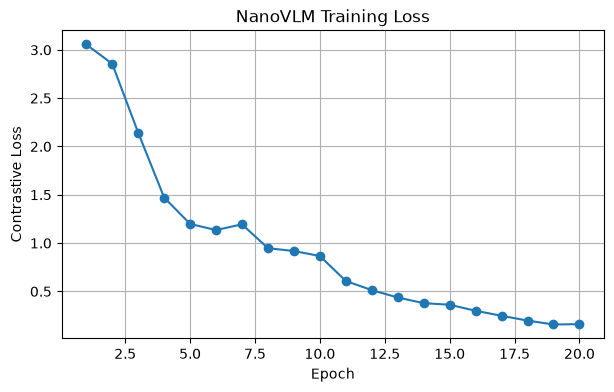

In [26]:
# Plot the training loss.

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("NanoVLM Training Loss")

plt.grid(True)
plt.show()

## 12. Inspect Learned Embeddings

A decreasing loss is useful, but we also want to see whether the shared embedding space is behaving as expected.

We take one batch and calculate:

```text
images
  ↓
Image Encoder
  ↓
image embeddings

captions
  ↓
Text Encoder
  ↓
text embeddings

In [27]:
# Switch to evaluation mode.

image_encoder.eval()
text_encoder.eval()


# Get one batch.

batch = next(iter(train_loader))

images, text_data = unpack_batch(batch)
tokens = prepare_text(text_data)


# Move to device.

images = images.to(DEVICE)
tokens = tokens.to(DEVICE)


# Generate embeddings.

with torch.no_grad():

    image_embeddings = image_encoder(images)

    text_embeddings = text_encoder(tokens)


# Normalize for cosine similarity.

image_embeddings = F.normalize(
    image_embeddings,
    dim=-1,
)

text_embeddings = F.normalize(
    text_embeddings,
    dim=-1,
)


# Calculate the similarity matrix.

similarity_matrix = (
    image_embeddings
    @ text_embeddings.T
)


print("Images:", images.shape)
print("Image embeddings:", image_embeddings.shape)

print("Tokens:", tokens.shape)
print("Text embeddings:", text_embeddings.shape)

print("Similarity matrix:", similarity_matrix.shape)

Images: torch.Size([32, 3, 32, 32])
Image embeddings: torch.Size([32, 64])
Tokens: torch.Size([32, 16])
Text embeddings: torch.Size([32, 64])
Similarity matrix: torch.Size([32, 32])


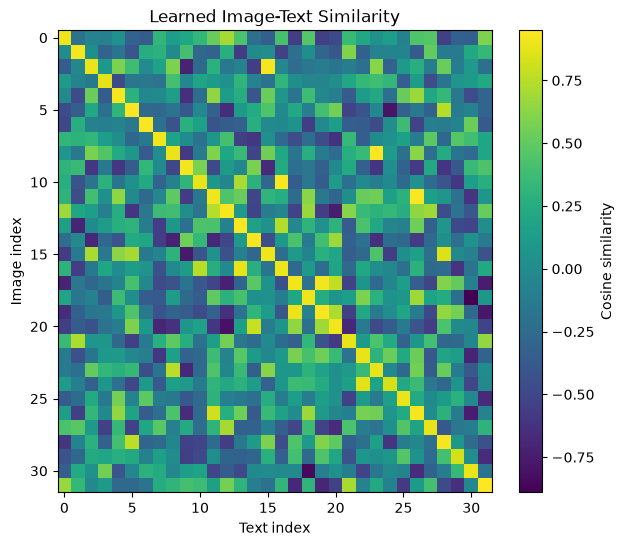

In [28]:
# Display the similarity matrix.

plt.figure(figsize=(7, 6))

plt.imshow(
    similarity_matrix.cpu().numpy(),
    aspect="auto",
)

plt.xlabel("Text index")
plt.ylabel("Image index")
plt.title("Learned Image-Text Similarity")

plt.colorbar(
    label="Cosine similarity"
)

plt.show()

## 13. Qualitative Retrieval Check

We can perform a simple retrieval experiment.

For each image:

1. Compare it with every caption in the batch.
2. Find the caption with the highest similarity.
3. Compare that predicted caption with the actual matching caption.

Because the dataset was constructed from aligned image-caption pairs, the expected correct caption is at the same batch index as the image.

For example:

```text
Image 0
   ↓
compare against captions 0...B-1
   ↓
highest similarity → Caption 0

In [29]:
# Number of examples to inspect.

NUM_EXAMPLES_TO_SHOW = min(
    5,
    images.shape[0],
)


# Find the highest-scoring caption for each image.

predicted_caption_indices = similarity_matrix.argmax(
    dim=1
)


for image_index in range(
    NUM_EXAMPLES_TO_SHOW
):

    predicted_index = (
        predicted_caption_indices[
            image_index
        ].item()
    )

    print("=" * 60)

    print(
        f"Image index: {image_index}"
    )

    print(
        f"Predicted caption index: "
        f"{predicted_index}"
    )

    print(
        f"Actual matching caption index: "
        f"{image_index}"
    )

    # If raw captions are available, print them.

    if isinstance(
        text_data,
        (list, tuple)
    ):

        print(
            "Predicted caption:",
            text_data[predicted_index]
        )

        print(
            "Actual caption:",
            text_data[image_index]
        )

    print(
        "Predicted similarity:",
        similarity_matrix[
            image_index,
            predicted_index
        ].item()
    )

    print(
        "Correct-pair similarity:",
        similarity_matrix[
            image_index,
            image_index
        ].item()
    )

Image index: 0
Predicted caption index: 0
Actual matching caption index: 0
Predicted caption: orange triangle bottom-right
Actual caption: orange triangle bottom-right
Predicted similarity: 0.9025421738624573
Correct-pair similarity: 0.9025421738624573
Image index: 1
Predicted caption index: 1
Actual matching caption index: 1
Predicted caption: yellow square top-left
Actual caption: yellow square top-left
Predicted similarity: 0.9261391162872314
Correct-pair similarity: 0.9261391162872314
Image index: 2
Predicted caption index: 15
Actual matching caption index: 2
Predicted caption: purple circle top-left
Actual caption: pink circle top-left
Predicted similarity: 0.9224269390106201
Correct-pair similarity: 0.8985154628753662
Image index: 3
Predicted caption index: 3
Actual matching caption index: 3
Predicted caption: brown triangle middle-left
Actual caption: brown triangle middle-left
Predicted similarity: 0.875243067741394
Correct-pair similarity: 0.875243067741394
Image index: 4
Pred

## Saving the Trained Model

After training, we save the learned weights so that the encoders can be loaded later without retraining.

The checkpoint is saved in the project's `checkpoints/` directory:

```text
Build-A-NanoVLM-From-Scratch/
├── checkpoints/
│   └── nanovlm_checkpoint.pt
└── notebooks/
    └── 06_training.ipynb

In [30]:
from pathlib import Path
import torch


# --------------------------------------------------
# Locate the project root
# --------------------------------------------------

# In this notebook:
# notebooks/06_training.ipynb
#
# Therefore the parent of the current working directory
# is normally the project root.

project_root = Path.cwd().parent

checkpoints_dir = project_root / "checkpoints"

# Create the checkpoints directory if it does not exist.
checkpoints_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# Checkpoint path
# --------------------------------------------------

checkpoint_path = (
    checkpoints_dir / "nanovlm_checkpoint.pt"
)


# --------------------------------------------------
# Save checkpoint
# --------------------------------------------------

checkpoint = {
    "epoch": NUM_EPOCHS,

    "image_encoder_state_dict":
        image_encoder.state_dict(),

    "text_encoder_state_dict":
        text_encoder.state_dict(),

    "optimizer_state_dict":
        optimizer.state_dict(),

    "training_losses":
        training_losses,

    # Store useful configuration information.
    "learning_rate":
        LEARNING_RATE,

    "projection_dim":
        PROJECTION_DIM,

    "embed_dim":
        EMBED_DIM,

    "attention_heads":
        ATTENTION_HEADS,

    "context_window":
        CONTEXT_WINDOW,

    "vocab_size":
        VOCAB_SIZE,
}


torch.save(
    checkpoint,
    checkpoint_path,
)


print("Checkpoint saved successfully!")
print(f"Path: {checkpoint_path}")
print(
    f"Size: "
    f"{checkpoint_path.stat().st_size / 1024:.2f} KB")

Checkpoint saved successfully!
Path: d:\github\Build A NanoVLM From SCRATCH\checkpoints\nanovlm_checkpoint.pt
Size: 5044.60 KB


# 14. Training Summary

We have now connected the complete NanoVLM training pipeline.

### 1. Dataset

The existing Dataset and DataLoader provide aligned image-text pairs.

### 2. Image Encoder

The CNN converts:

$$
[B,3,32,32]
$$

into:

$$
[B,64]
$$

image embeddings.

### 3. Text Encoder

The Transformer-based text encoder converts tokenized captions into:

$$
[B,64]
$$

text embeddings.

### 4. Similarity Matrix

Every image is compared with every caption:

$$
S = Z_I Z_T^T
$$

producing:

$$
[B,B]
$$

similarity scores.

### 5. Contrastive Loss

The diagonal contains the positive pairs.

The off-diagonal entries provide negative examples.

The symmetric loss is:

$$
L =
\frac{
L_{I\rightarrow T}
+
L_{T\rightarrow I}
}{2}
$$

### 6. Backpropagation

The loss produces gradients for both encoders.

```text
Contrastive Loss
       ↓
   Backpropagation
       ↓
 ┌───────────────┐
 ↓               ↓
Image Encoder   Text Encoder